In [48]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

from hmmlearn.hmm import GaussianHMM

import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv(
    r"C:/A-CMSI research/Data/HMM data/HMM_Input_features.csv"
)

df.head()

,Date,SPY_Return,SPY_V,RollingVol21,RollingSkew21,Drawdown,VolOfVol,VIX,C_t
0,2016-01-04,-0.014078,0.625878,0.011695,0.098234,-0.043852,0.000981,20.700001,0.828265
1,2016-01-05,0.001690,1.047069,0.011344,-0.024522,-0.042234,0.000862,19.340000,0.801967
2,2016-01-06,-0.012695,0.768872,0.010648,-0.000368,-0.054316,0.000815,20.590000,0.758904
3,2016-01-07,-0.024284,1.088437,0.011669,-0.115220,-0.077004,0.000800,24.990000,0.811198
4,2016-01-08,-0.011037,2.182559,0.011773,-0.072950,-0.087135,0.000784,27.010000,0.791320


In [50]:
df.info()

df.describe()

df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           2513 non-null   str    
 1   SPY_Return     2513 non-null   float64
 2   SPY_V          2513 non-null   float64
 3   RollingVol21   2513 non-null   float64
 4   RollingSkew21  2513 non-null   float64
 5   Drawdown       2513 non-null   float64
 6   VolOfVol       2513 non-null   float64
 7   VIX            2513 non-null   float64
 8   C_t            2513 non-null   float64
dtypes: float64(8), str(1)
memory usage: 201.4 KB


Date             0
SPY_Return       0
SPY_V            0
RollingVol21     0
RollingSkew21    0
Drawdown         0
VolOfVol         0
VIX              0
C_t              0
dtype: int64

In [51]:
features = [
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "RollingSkew21",
    "Drawdown",
    "VolOfVol",
    "VIX",
    "C_t"
]

X = df[features]

In [52]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [53]:
X_scaled.mean(axis=0)

X_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1.])

In [54]:
best_model = None
best_score = -np.inf

for seed in range(30):

    model = GaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=200,
        random_state=seed
    )

    model.fit(X_scaled)

    score = model.score(X_scaled)

    if score > best_score:

        best_score = score
        best_model = model

print(best_score)

-15145.500630178913


In [55]:
hidden_states = best_model.predict(X_scaled)

df["State"] = hidden_states

In [56]:
state_prob = best_model.predict_proba(X_scaled)

In [57]:
df.groupby("State")[[
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "Drawdown",
    "VIX"
]].mean()

,SPY_Return,SPY_V,RollingVol21,Drawdown,VIX
State,,,,,
0,0.000257,0.358597,0.011116,-0.086938,20.122937
1,0.001037,-0.635040,0.005988,-0.005574,14.776909
2,-0.000399,0.736438,0.017103,-0.072047,27.201192


In [58]:
state_names = {
    0: "Neutral",
    1: "Bull",
    2: "Panic"
}

df["Regime"] = df["State"].map(state_names)

In [59]:
df["P_t"] = state_prob[:, 2]

In [60]:
print(best_model.transmat_)

[[0.97967501 0.01483166 0.00549333]
 [0.00697428 0.98300341 0.01002231]
 [0.02292675 0.0244076  0.95266566]]


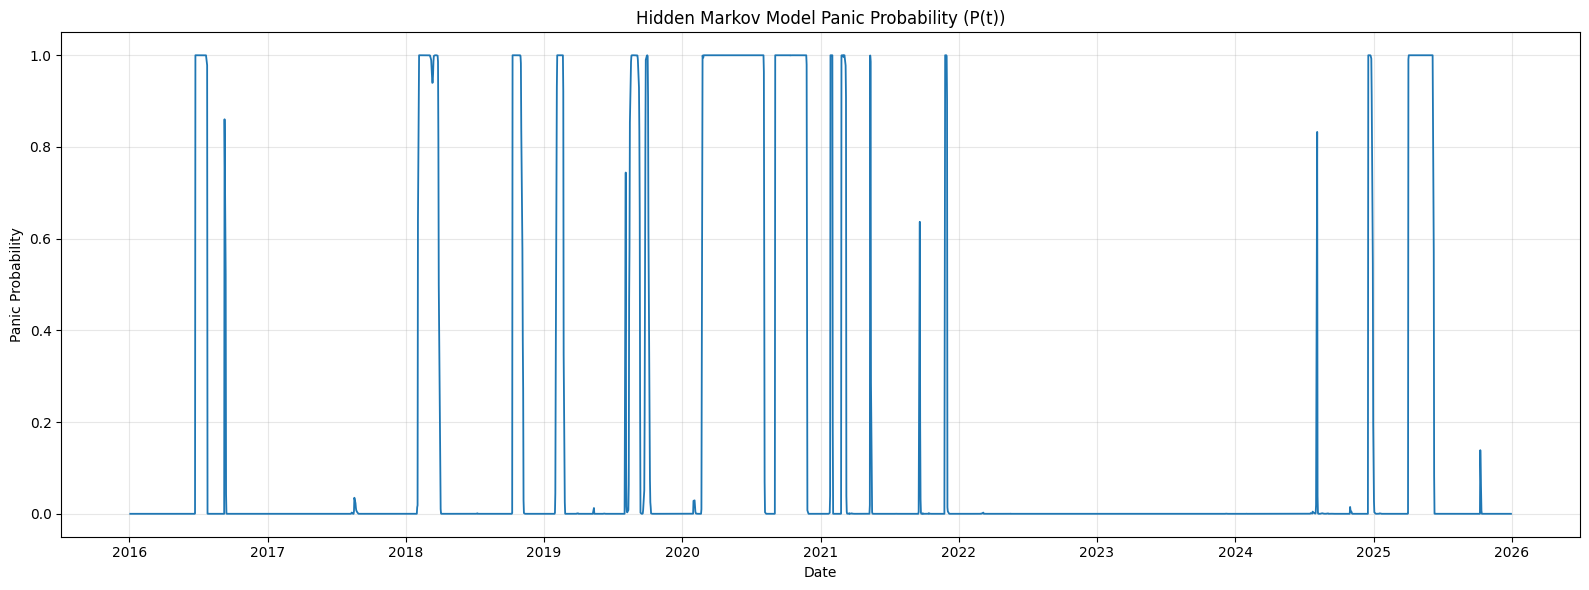

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(
    pd.to_datetime(df["Date"]),
    df["P_t"],
    linewidth=1.3
)

plt.title("Hidden Markov Model Panic Probability (P(t))")
plt.xlabel("Date")
plt.ylabel("Panic Probability")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

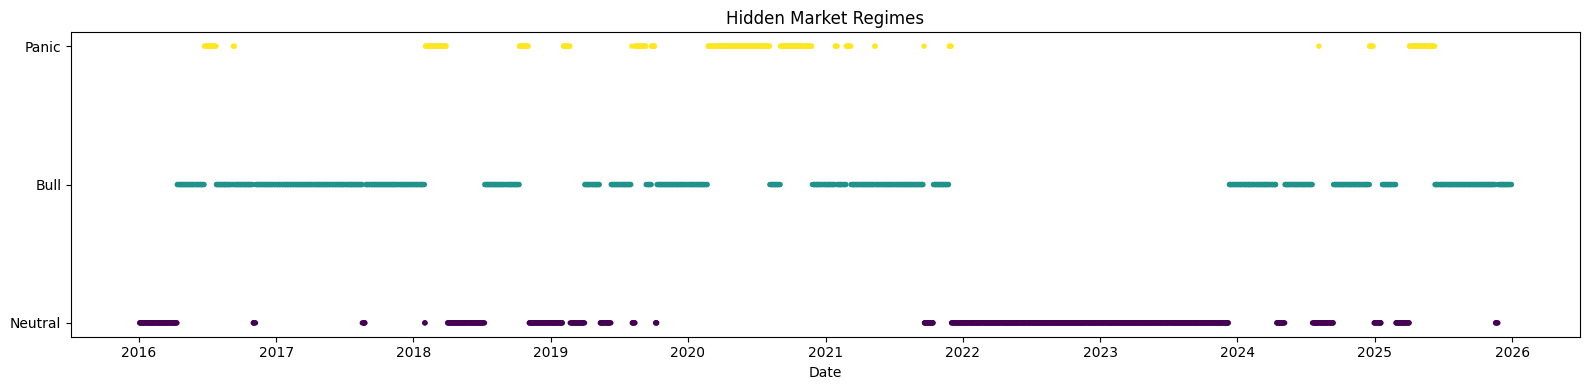

In [62]:
plt.figure(figsize=(16,4))

plt.scatter(
    pd.to_datetime(df["Date"]),
    df["State"],
    c=df["State"],
    cmap="viridis",
    s=8
)

plt.yticks([0,1,2],["Neutral","Bull","Panic"])

plt.title("Hidden Market Regimes")

plt.xlabel("Date")

plt.tight_layout()
plt.show()

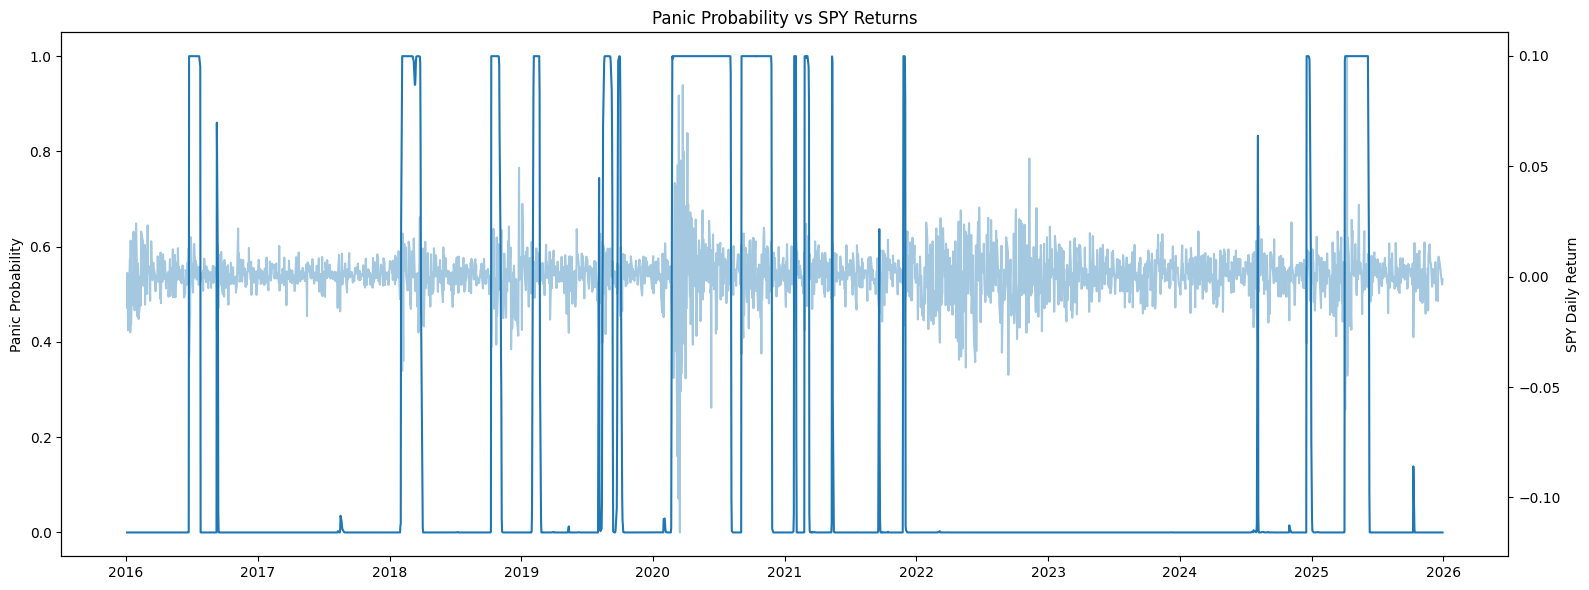

In [63]:
fig, ax1 = plt.subplots(figsize=(16,6))

ax1.plot(
    pd.to_datetime(df["Date"]),
    df["P_t"],
    label="Panic Probability",
    linewidth=1.5
)

ax1.set_ylabel("Panic Probability")

ax2 = ax1.twinx()

ax2.plot(
    pd.to_datetime(df["Date"]),
    df["SPY_Return"],
    alpha=0.4
)

ax2.set_ylabel("SPY Daily Return")

plt.title("Panic Probability vs SPY Returns")

plt.tight_layout()
plt.show()

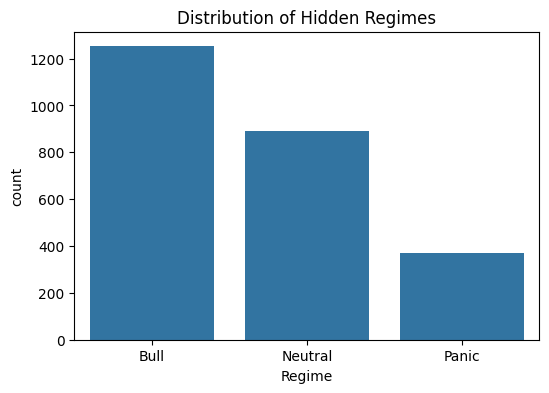

In [64]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Regime",
    order=["Bull","Neutral","Panic"]
)

plt.title("Distribution of Hidden Regimes")

plt.show()

In [65]:
print(best_model.means_)

[[-0.03089213  0.41084104  0.25823227  0.19310462 -0.74302499 -0.14046219
   0.22317924  0.44291125]
 [ 0.04440285 -0.51598891 -0.53423234  0.034138    0.67357353 -0.32708945
  -0.50842077 -0.54676836]
 [-0.07584784  0.75560323  1.18777269 -0.58438597 -0.48490167  1.45152605
   1.18515374  0.78232888]]


In [66]:
import pandas as pd

means = pd.DataFrame(
    scaler.inverse_transform(best_model.means_),
    columns=features
)

print(means)

   SPY_Return     SPY_V  RollingVol21  RollingSkew21  Drawdown  VolOfVol  \
0    0.000198  0.361259      0.011109      -0.044631 -0.086854  0.001242   
1    0.001054 -0.636361      0.005988      -0.146876 -0.005562  0.000907   
2   -0.000313  0.732354      0.017116      -0.544702 -0.072042  0.004100   

         VIX       C_t  
0  20.134950  0.736924  
1  14.771652  0.548981  
2  27.187104  0.801381  


In [67]:
print(best_model.covars_)

[[[ 1.05944756e+00  1.88848575e-02  5.26961190e-03  7.03521668e-02
    1.10114136e-01  1.02584270e-02 -1.40881608e-01 -2.45338848e-02]
  [ 1.88848575e-02  1.22418224e+00  3.00092883e-01 -2.60603111e-01
   -7.74898436e-02  1.60697402e-01  4.64950648e-01  2.47978560e-01]
  [ 5.26961190e-03  3.00092883e-01  3.71126525e-01  6.55486291e-02
   -3.99888688e-01  8.86779868e-02  3.14730346e-01  3.21220174e-01]
  [ 7.03521668e-02 -2.60603111e-01  6.55486291e-02  5.47415355e-01
   -1.68536528e-01 -7.53600576e-05 -6.01854492e-04  5.22735435e-02]
  [ 1.10114136e-01 -7.74898436e-02 -3.99888688e-01 -1.68536528e-01
    1.02148690e+00 -2.39268535e-02 -4.99098731e-01 -3.56517629e-01]
  [ 1.02584270e-02  1.60697402e-01  8.86779868e-02 -7.53600576e-05
   -2.39268535e-02  1.52917984e-01  5.67769574e-02  4.43594074e-02]
  [-1.40881608e-01  4.64950648e-01  3.14730346e-01 -6.01854492e-04
   -4.99098731e-01  5.67769574e-02  5.02380012e-01  2.79134904e-01]
  [-2.45338848e-02  2.47978560e-01  3.21220174e-01  5.2

In [68]:
print("Log-Likelihood:", best_model.score(X_scaled))

Log-Likelihood: -15145.500630178913


In [69]:
import pandas as pd

transition_full = pd.DataFrame(
    best_model.transmat_,
    index=["From_State0", "From_State1", "From_State2"],
    columns=["To_State0", "To_State1", "To_State2"]
)

print(transition_full)

transition_full.to_csv(
    r"C:\A-CMSI research\Data\HMM data\TransitionMatrix_FullCov.csv",
    index=True
)

             To_State0  To_State1  To_State2
From_State0   0.979675   0.014832   0.005493
From_State1   0.006974   0.983003   0.010022
From_State2   0.022927   0.024408   0.952666


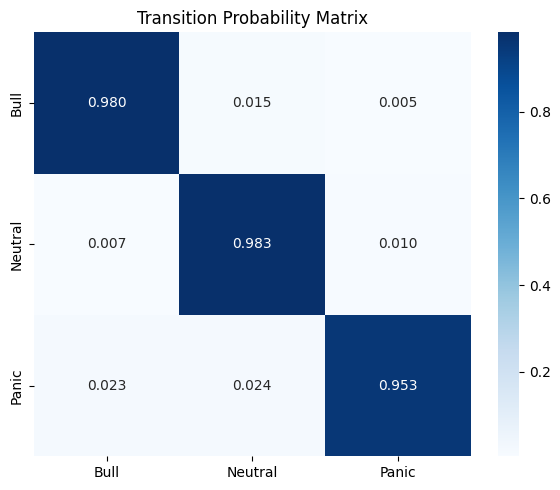

In [70]:
transition = pd.DataFrame(
    best_model.transmat_,
    index=["Bull","Neutral","Panic"],
    columns=["Bull","Neutral","Panic"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    transition,
    annot=True,
    cmap="Blues",
    fmt=".3f"
)

plt.title("Transition Probability Matrix")

plt.tight_layout()

plt.show()

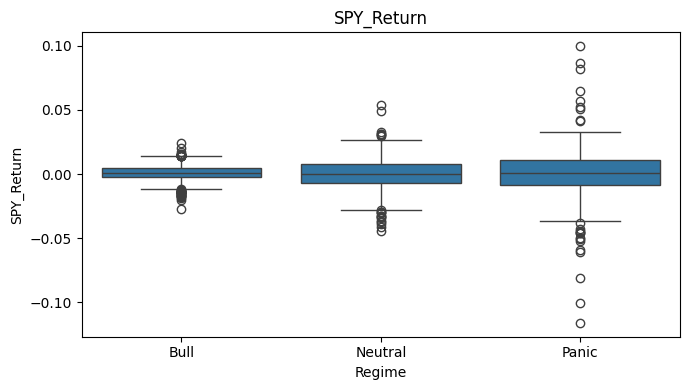

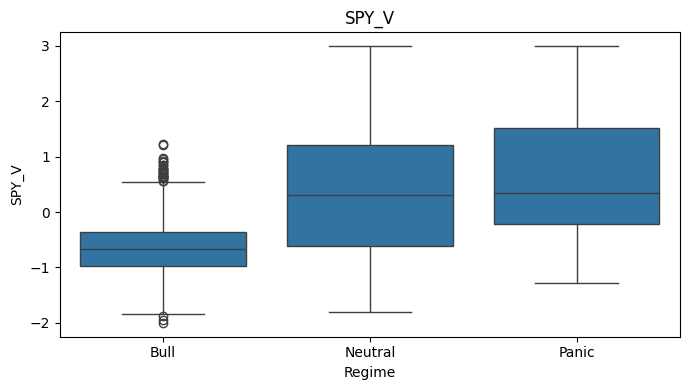

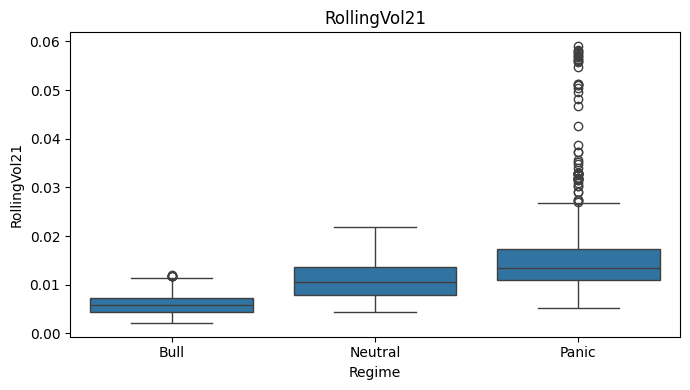

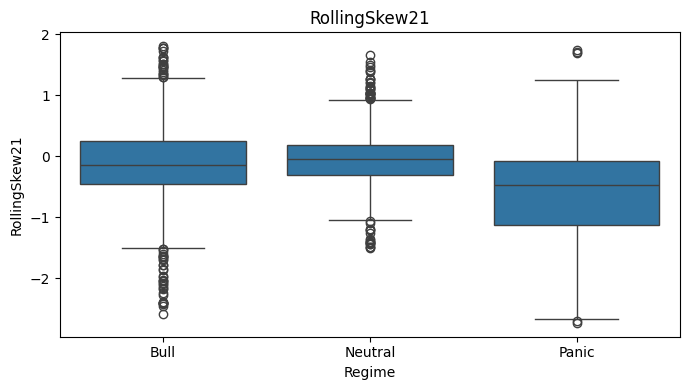

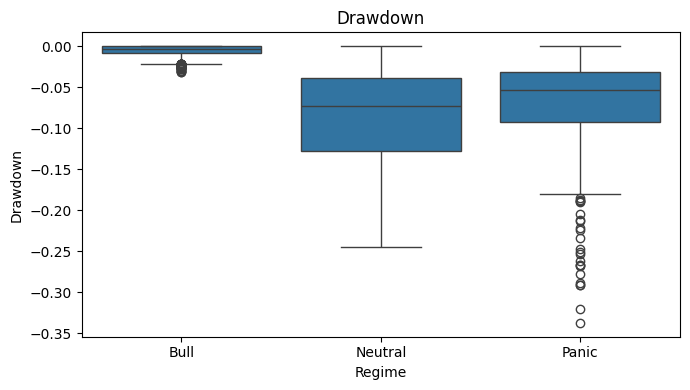

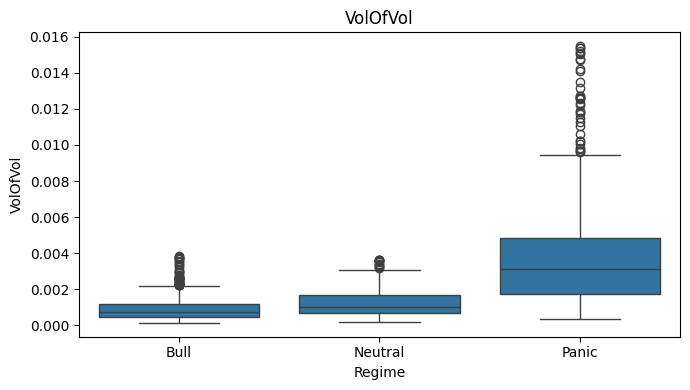

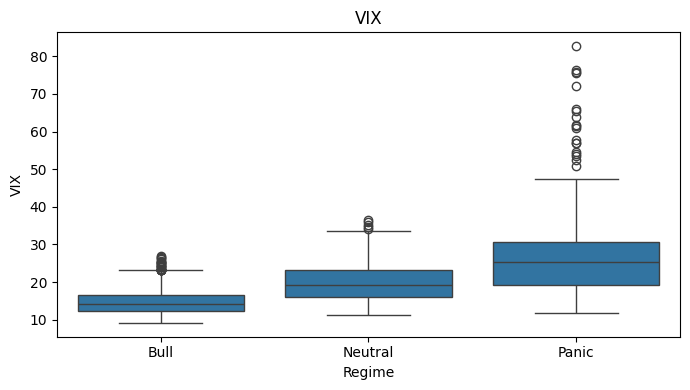

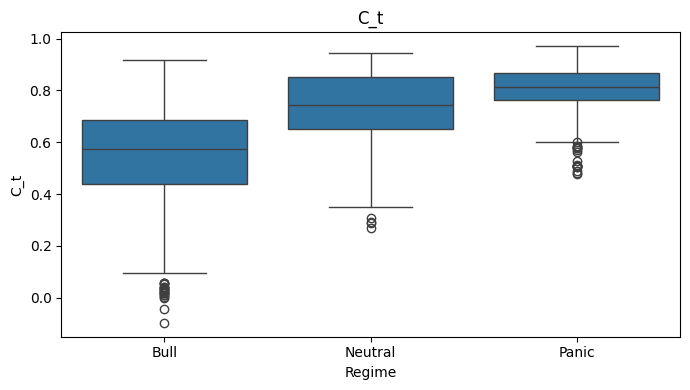

In [71]:
features = [
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "RollingSkew21",
    "Drawdown",
    "VolOfVol",
    "VIX",
    "C_t"
]

for feature in features:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=df,
        x="Regime",
        y=feature,
        order=["Bull","Neutral","Panic"]
    )

    plt.title(feature)

    plt.tight_layout()

    plt.show()

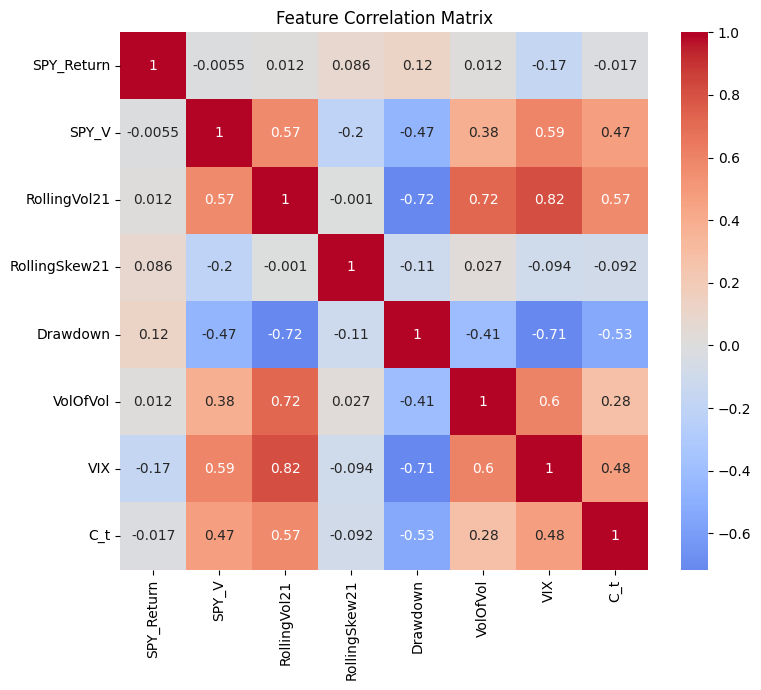

In [72]:
plt.figure(figsize=(8,7))

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

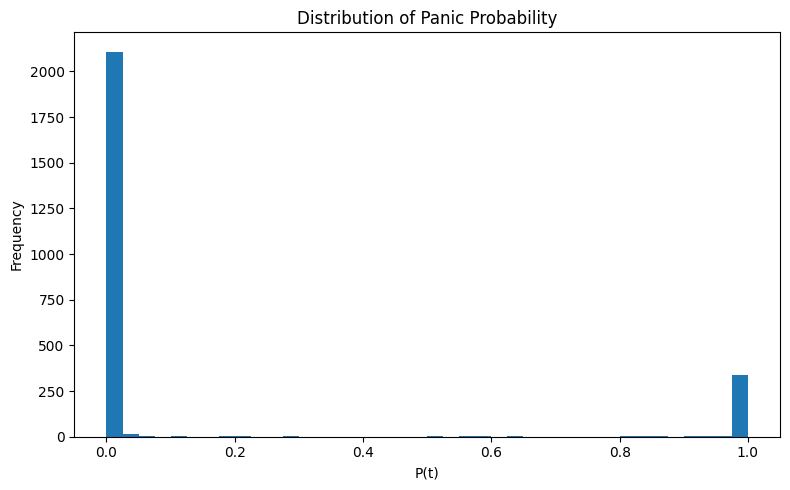

In [73]:
plt.figure(figsize=(8,5))

plt.hist(
    df["P_t"],
    bins=40
)

plt.title("Distribution of Panic Probability")

plt.xlabel("P(t)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [74]:
prices = pd.read_csv(
    r"C:\A-CMSI research\Data\prices_clean.csv"
)

prices["Date"] = pd.to_datetime(
    prices["Date"],
    dayfirst=True
)

df["Date"] = pd.to_datetime(
    df["Date"]
)

In [75]:
plot_df = pd.merge(
    prices[["Date", "SPY"]],
    df[["Date", "Regime"]],
    on="Date",
    how="inner"
)

In [76]:
print(plot_df.head())
print(plot_df.shape)

        Date         SPY   Regime
0 2016-01-04  169.908188  Neutral
1 2016-01-05  170.195541  Neutral
2 2016-01-06  168.048676  Neutral
3 2016-01-07  164.016907  Neutral
4 2016-01-08  162.216522  Neutral
(2513, 3)


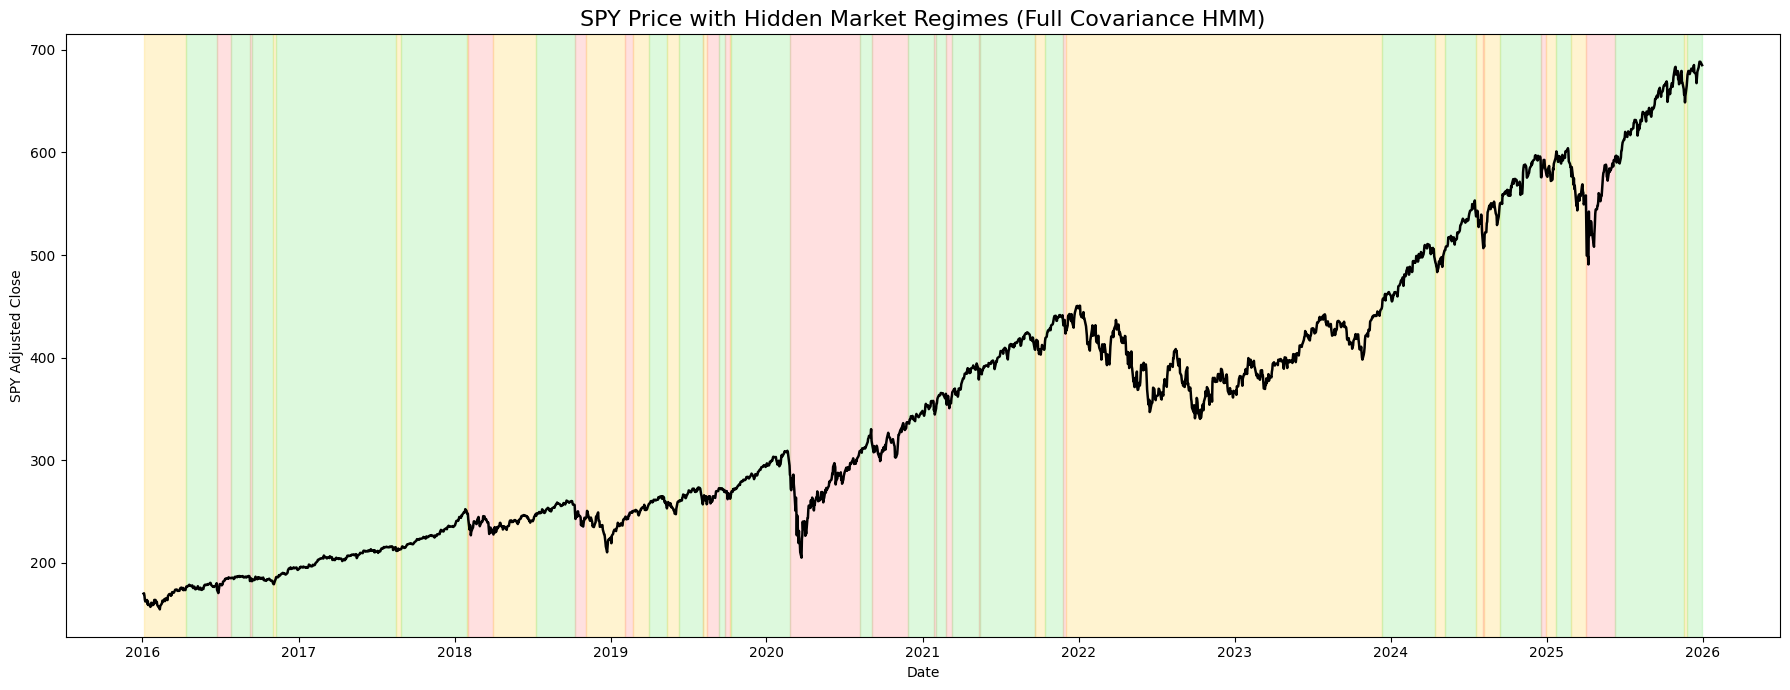

In [77]:
import matplotlib.pyplot as plt

colors = {
    "Bull": "#90EE90",      # light green
    "Neutral": "#FFD966",   # light yellow
    "Panic": "#FF9999"      # light red
}

fig, ax = plt.subplots(figsize=(18,7))

# SPY Price
ax.plot(
    plot_df["Date"],
    plot_df["SPY"],
    color="black",
    linewidth=1.8,
    label="SPY"
)

# Shade continuous regimes
start = 0

for i in range(1, len(plot_df)):

    if plot_df["Regime"].iloc[i] != plot_df["Regime"].iloc[start]:

        ax.axvspan(
            plot_df["Date"].iloc[start],
            plot_df["Date"].iloc[i],
            color=colors[plot_df["Regime"].iloc[start]],
            alpha=0.30
        )

        start = i

# Shade final regime
ax.axvspan(
    plot_df["Date"].iloc[start],
    plot_df["Date"].iloc[-1],
    color=colors[plot_df["Regime"].iloc[start]],
    alpha=0.30
)

ax.set_title(
    "SPY Price with Hidden Market Regimes (Full Covariance HMM)",
    fontsize=16
)

ax.set_xlabel("Date")
ax.set_ylabel("SPY Adjusted Close")

plt.tight_layout()

plt.show()

In [78]:
durations = []

current = df["Regime"].iloc[0]
length = 1

for regime in df["Regime"].iloc[1:]:

    if regime == current:

        length += 1

    else:

        durations.append({
            "Regime": current,
            "Duration": length
        })

        current = regime
        length = 1

durations.append({
    "Regime": current,
    "Duration": length
})

duration_df = pd.DataFrame(durations)

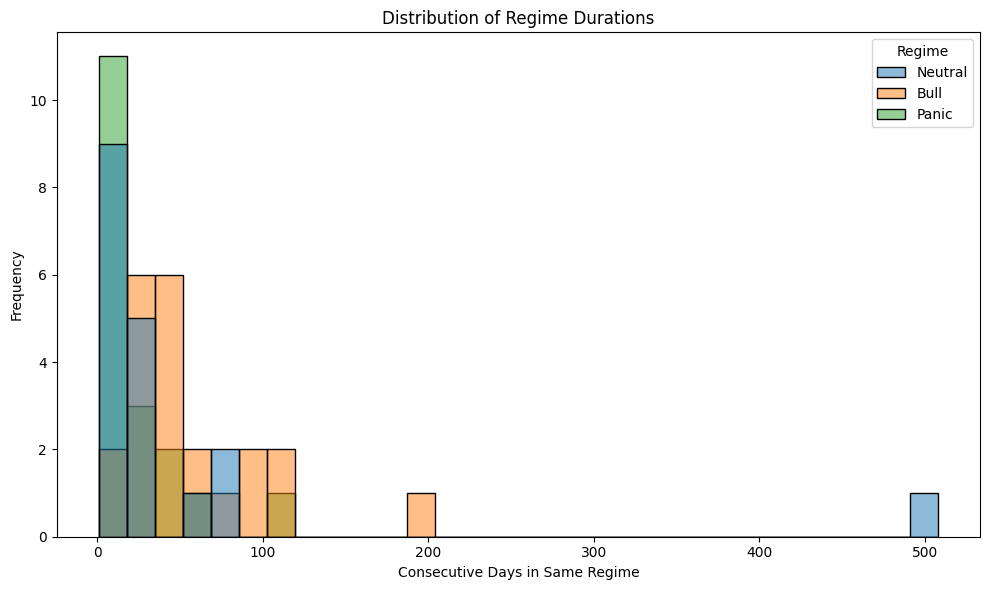

In [79]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=duration_df,
    x="Duration",
    hue="Regime",
    multiple="layer",
    bins=30
)

plt.title("Distribution of Regime Durations")

plt.xlabel("Consecutive Days in Same Regime")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [80]:
duration_summary = duration_df.groupby("Regime")["Duration"].agg([
    "count",
    "mean",
    "median",
    "max"
])

print(duration_summary)

         count       mean  median  max
Regime                                
Bull        22  56.909091    42.0  195
Neutral     18  49.555556    17.0  508
Panic       18  20.500000     8.0  115


In [81]:
state_means = df.groupby("Regime")[[
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "RollingSkew21",
    "Drawdown",
    "VolOfVol",
    "VIX",
    "C_t"
]].mean()

state_means.to_csv(
    r"C:\A-CMSI research\Data\HMM data\StateMeans.csv"
)

print(state_means)

         SPY_Return     SPY_V  RollingVol21  RollingSkew21  Drawdown  \
Regime                                                                 
Bull       0.001037 -0.635040      0.005988      -0.147250 -0.005574   
Neutral    0.000257  0.358597      0.011116      -0.043153 -0.086938   
Panic     -0.000399  0.736438      0.017103      -0.545880 -0.072047   

         VolOfVol        VIX       C_t  
Regime                                  
Bull     0.000906  14.776909  0.548804  
Neutral  0.001243  20.122937  0.737063  
Panic    0.004095  27.201192  0.802055  


In [82]:
posterior_df = pd.DataFrame(
    state_prob,
    columns=["Prob_State0","Prob_State1","Prob_State2"]
)

posterior_df.insert(0, "Date", df["Date"])

posterior_df.to_csv(
    r"C:\A-CMSI research\Data\HMM data\PosteriorProbabilities.csv",
    index=False
)

In [83]:
df.to_csv(
    r"C:\A-CMSI research\Data\HMM data\HMM_Output.csv",
    index=False
)

In [84]:
logL = best_model.score(X_scaled)

print(logL)

-15145.500630178913


In [85]:
n = X_scaled.shape[0]

In [86]:
K = best_model.n_components
d = X_scaled.shape[1]

num_params = (
    (K - 1)
    + K*(K - 1)
    + K*d
    + K*d*(d + 1)/2
)

print(num_params)

140.0


In [87]:
AIC = 2*num_params - 2*logL

In [88]:
import numpy as np

BIC = np.log(n)*num_params - 2*logL

In [89]:
print("Log-Likelihood :", logL)
print("Parameters     :", num_params)
print("AIC            :", AIC)
print("BIC            :", BIC)

Log-Likelihood : -15145.500630178913
Parameters     : 140.0
AIC            : 30571.001260357825
BIC            : 31387.093815613927


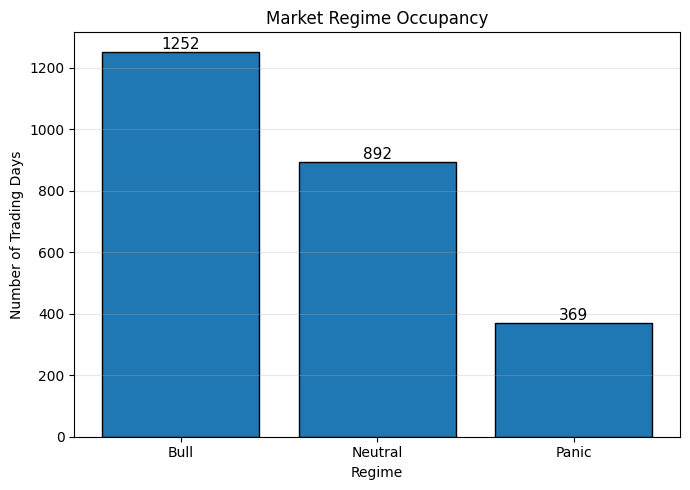

In [90]:
import matplotlib.pyplot as plt

regime_counts = df["Regime"].value_counts()

plt.figure(figsize=(7,5))

bars = plt.bar(
    regime_counts.index,
    regime_counts.values,
    edgecolor="black"
)

plt.title("Market Regime Occupancy")
plt.xlabel("Regime")
plt.ylabel("Number of Trading Days")

# Add counts above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 10,
        f"{int(height)}",
        ha="center",
        fontsize=11
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

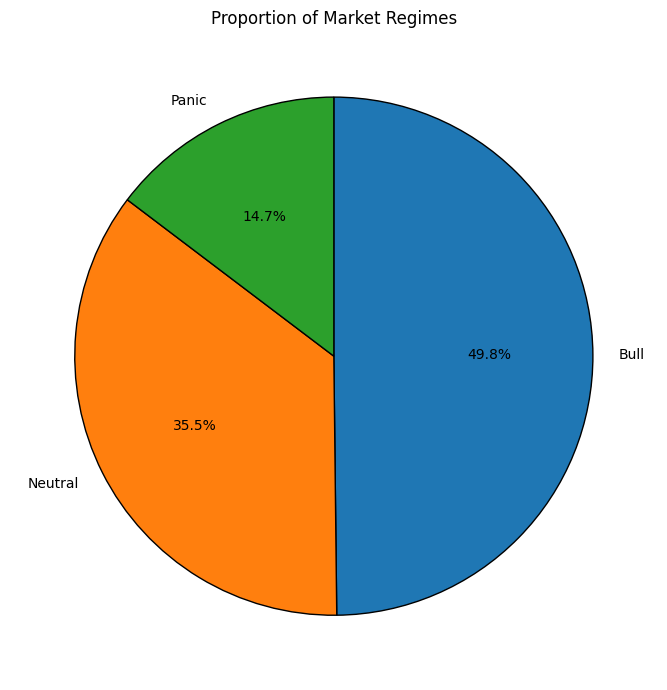

In [91]:
import matplotlib.pyplot as plt

regime_counts = df["Regime"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    regime_counts,
    labels=regime_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops=dict(edgecolor="black")
)

plt.title("Proportion of Market Regimes")

plt.tight_layout()
plt.show()